# 🌤️ PROJE 5 — Hava: Malatya + 3 İl + İklim Değişikliği
## Mini Proje — Araştırma Projeniz
*Bugün (Gün 2) seçtiğiniz proje — kampın son günü "Bilimsel Yöntem" oturumunda sunulacak*

**Veri seti:** Malatya, İstanbul, Erzurum 2020-2024 (toplam 5481 günlük gözlem)
**Kaynak:** Open-Meteo (ERA5 yeniden analizi) — GERÇEK verilerdir

### 🎯 Sizin Göreviniz
Hava modellerini eğitmek + **iklim değişikliği gözlemi** + il karşılaştırma!

**Aşağıdaki seçeneklerden en az 3'ünü deneyin:**
1. **1-gün vs 3-gün tahmin** karşılaştırması (RMSE artışı)
2. **Mevsim bazında** model performansı
3. 🌡️ **İklim değişikliği:** 2020 → 2024 arası sıcaklık değişti mi? (3 il)
4. 🔥 **Aşırı sıcaklık olayları:** >35°C kaç gün, yıllar arası fark
5. 🌧️ **Yağış-sıcaklık ilişkisi:** Yağmurlu günler gerçekten serin mi?
6. 🏙️ **3 il karşılaştırma:** Malatya vs İstanbul vs Erzurum
7. **Tek model 3 il için çalışır mı?** Eğitim Malatya, test İstanbul/Erzurum (transfer öğrenimi)

---

> 🤖 **Bu, defterin "çıktılı önizleme" sürümüdür.** Asıl çalışacağınız Colab defteri
> [`notebooks/`](../notebooks) klasöründe. Buraya, normal hücrelerin **arasına**:
> 📂 *veri açıklamaları*, 📊 *her grafiğin/istatistiğin ne anlattığı*, 🔧 *deneyebileceğiniz
> varyasyonlar* (çalıştırılmış hâlde) ve mini projelerde 🎤 *sunum rehberleri* eklendi.
> Bu eklemeler **alıntı kutularıyla** ayrılmıştır; siz de aynı şeyleri kendi defterinizde deneyebilirsiniz.


📊 **‘1-gün vs 3-gün’ sonucu:** 3-gün sonrası tahminin RMSE'si (hatası), 1-gün sonrasından **belirgin daha büyüktür**. Sezgisel: gelecek ne kadar uzaksa belirsizlik o kadar artar. Gerçek meteoroloji de bunu yaşar — bu yüzden 10 günlük tahminlere 5 günlük kadar güvenmeyiz. ‘Tahmin ufku uzadıkça doğruluk düşer.’

In [2]:
import os
from python_code.helper_tr import *
import pandas as pd
import numpy as np

hava = pd.read_csv('input_data/iller_hava.csv')
hava['tarih'] = pd.to_datetime(hava['tarih'])
print(f'\nİl sayısı: {hava["il"].nunique()}')
print(f'Toplam: {len(hava)} günlük gözlem')
print(f'Yıl aralığı: {hava["yil"].min()} - {hava["yil"].max()}')



İl sayısı: 3
Toplam: 5481 günlük gözlem
Yıl aralığı: 2020 - 2024


## 📂 Veriyi Tanıyalım — 3 İlin Hava Durumu (2020–2024)

**Malatya, İstanbul ve Erzurum** için 5 yıllık **günlük** hava kayıtları. Her satır **bir ilin bir günüdür**.

- **Satır sayısı:** 5.481 günlük gözlem (3 il × ~5 yıl)
- **Zaman aralığı:** 2020 – 2024
- **Şehirler bilerek farklı:** Erzurum yüksek-soğuk (ort ~7,5 °C), İstanbul ılıman-nemli (~15,4 °C), Malatya karasal (~15 °C)

| Sütun | Anlamı |
|---|---|
| `il` | Şehir (Malatya / İstanbul / Erzurum) |
| `tarih` | Gözlem günü |
| `sicaklik_ort / min / max` | Günlük ortalama / en düşük / en yüksek sıcaklık (°C) |
| `yagis` | Günlük yağış (mm) |
| `ruzgar_max` | Günün en yüksek rüzgârı |
| `yil, ay, gun, mevsim` | Tarih bilgileri (modelde ipucu olur) |

💬 **Akranlarına anlat:** *“Dünün havasına bakıp yarını tahmin edebilir miyiz? Hangi şehir daha ‘tahmin edilebilir’? Ve 5 yılda iklim ısındı mı?”*

---
### 👥 Grup Tartışması — Başlamadan Önce
- Malatya, İstanbul ve Erzurum'dan hangisi en **sıcak**, hangisi en **soğuk**, hangisi en **değişken** sizce? Grupça tahmin edin, sonra veriye bakacağız.
- Yaşadığınız yerin havası son yıllarda değişti mi? Büyükleriniz ne diyor?

## Adım 1: 3 İl Genel Karşılaştırma 🏙️

📦 Kutu grafiği: sicaklik_ort (gruplar: il)


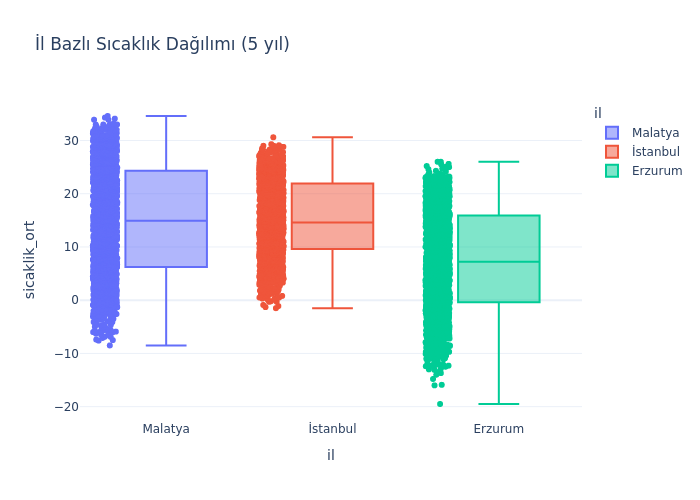

In [3]:
kutu_grafigi(hava, kategori_sutunu='il', sayisal_sutun='sicaklik_ort',
             baslik='İl Bazlı Sıcaklık Dağılımı (5 yıl)')

📊 **İl sıcaklık kutu grafiği:** Her ilin sıcaklık **dağılımını** (sadece ortalamayı değil) gösterir. Kutu ne kadar **uzunsa** o ilde sıcaklık o kadar çok oynar (karasal iklim). Erzurum'un hem düşük hem geniş olması beklenir.

🔧 **Sıcaklık yerine yağışa bak.** Aynı fonksiyon, farklı sütun:

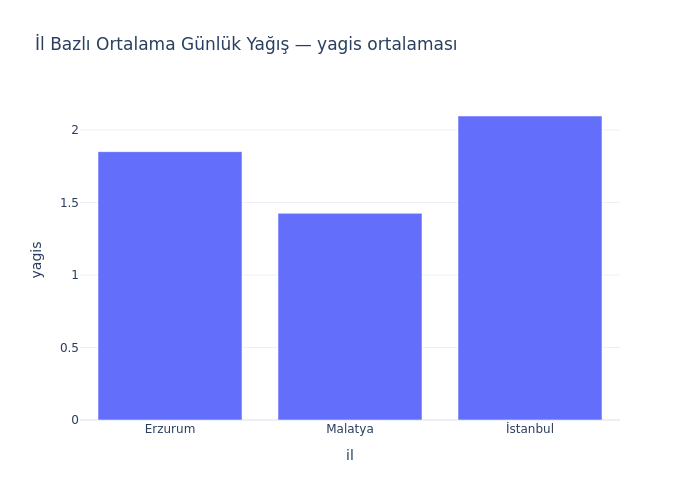

In [4]:
cubuk_grafigi(hava, kategori_sutunu='il', deger_sutunu='yagis',
              baslik='İl Bazlı Ortalama Günlük Yağış')

📊 En sıcak il en kurak olmak zorunda değildir; iklim sıcaklık + yağış + rüzgârın **birlikte** belirlediği bir resimdir. Bir şehri tek sayıyla değil, birkaç ölçüyle birden tanımla.

In [5]:
ozet = hava.groupby('il').agg({
    'sicaklik_ort': ['mean', 'min', 'max', 'std'],
    'yagis': 'sum',
}).round(1)
print(ozet)

         sicaklik_ort                     yagis
                 mean   min   max   std     sum
il                                             
Erzurum           7.5 -19.5  26.0   9.5  3380.5
Malatya          15.0  -8.5  34.6  10.2  2603.3
İstanbul         15.4  -1.5  30.6   7.1  3829.6


📊 **İl özet tablosu:** Her ilin ortalama/min/max sıcaklığı, **değişkenliği (std)** ve toplam yağışı. **std (standart sapma)** = sıcaklığın ne kadar oynadığı; karasal illerde (Erzurum/Malatya) yüksek, deniz etkili İstanbul'da düşüktür. En sıcak ≠ en yağışlı — bu yüzden birkaç sütuna birden bakmak gerekir.

**Görev:** Hangi il en sıcak? En soğuk? En değişken (std en yüksek)? En yağışlı?

## 🌡️ Adım 2: İklim Değişikliği Gözlemi (2020 → 2024)

**Hipotez:** 5 yıl içinde sıcaklık trendi yukarı mı, aşağı mı, sabit mi?

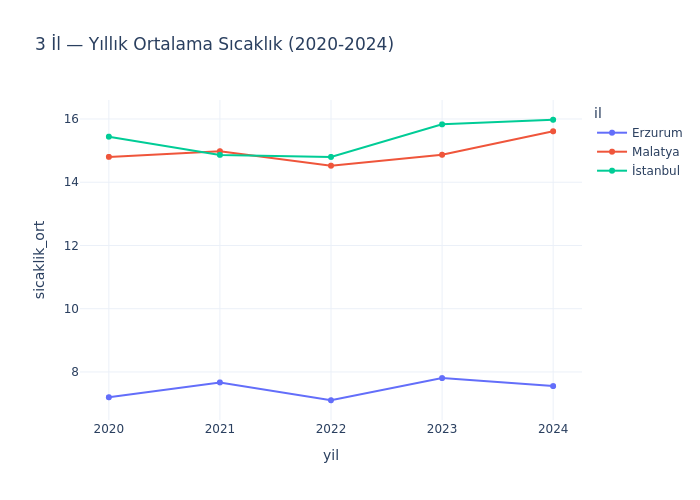

In [6]:
yillik = hava.groupby(['il', 'yil'])['sicaklik_ort'].mean().reset_index()
import plotly.express as px
fig = px.line(yillik, x='yil', y='sicaklik_ort', color='il', markers=True,
              title='3 İl — Yıllık Ortalama Sıcaklık (2020-2024)')
fig.show()

📊 **Yıllık ortalama trend:** 2020→2024 çizgileri genelde **yukarı** eğilimli — kısa pencerede bile bir ısınma sinyali. ⚠️ Ama 5 yıl, iklim için **çok kısadır**; bunu ‘kesin trend’ değil bir ‘gözlem’ olarak sun. Gerçek iklim trendleri için onlarca yıllık veri gerekir.

In [7]:
for il in hava['il'].unique():
    veri_2020 = hava[(hava['il']==il) & (hava['yil']==2020)]['sicaklik_ort'].mean()
    veri_2024 = hava[(hava['il']==il) & (hava['yil']==2024)]['sicaklik_ort'].mean()
    print(f'{il:10}: 2020={veri_2020:.2f}°C, 2024={veri_2024:.2f}°C, Δ={veri_2024-veri_2020:+.2f}°C')

Malatya   : 2020=14.80°C, 2024=15.61°C, Δ=+0.81°C
İstanbul  : 2020=15.44°C, 2024=15.98°C, Δ=+0.54°C
Erzurum   : 2020=7.20°C, 2024=7.55°C, Δ=+0.35°C


📊 **2020 vs 2024 farkı:** Her ilin iki yıl arasındaki ortalama sıcaklık değişimi (Δ). Hangi il en çok ısınmış görünüyor? ⚠️ Tek bir yıl çok değişken olabilir (örn. 2020 rastgele soğuk bir yıl olabilir), bu yüzden tek bir fark ‘şans mı, gerçek trend mi’ ayırmaz — birden çok yıla bakmak şarttır.

**Görev:** Hangi il en çok ısındı? Bu "sadece şans mı" yoksa "trend mi"? 5 yıl trend için yeterli mi? (Gerçek iklim biliminde 30 yıl gerek)

---
### 👥 Grup Tartışması
- Sadece **5 yıllık** veriyle 'iklim değişiyor' demek doğru mu? Bir trendi güvenle söylemek için ne kadar veri gerekir?
- 'Bu yıl çok sıcaktı' demek ile 'iklim ısınıyor' demek aynı şey mi? **Hava** (weather) ile **iklim** (climate) farkını tartışın.

## 🔥 Adım 3: Aşırı Sıcaklık Olayları

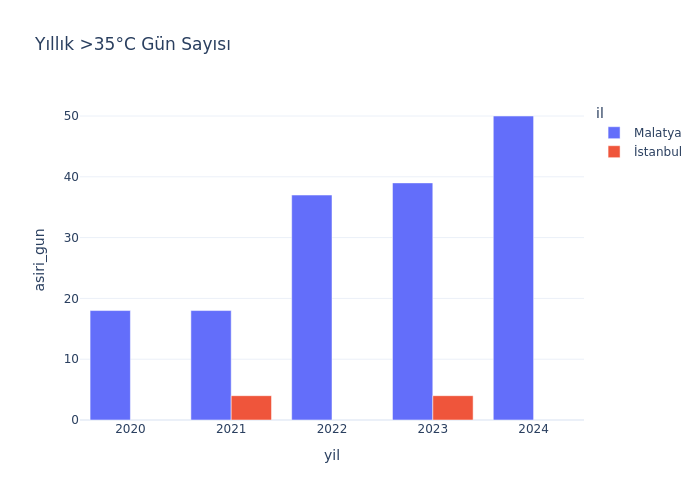


İl × Yıl tablosu:
il    Malatya  İstanbul
yil                    
2020       18         0
2021       18         4
2022       37         0
2023       39         4
2024       50         0


In [8]:
asiri = hava[hava['sicaklik_max'] > 35].groupby(['il', 'yil']).size().reset_index(name='asiri_gun')
fig = px.bar(asiri, x='yil', y='asiri_gun', color='il', barmode='group',
             title='Yıllık >35°C Gün Sayısı')
fig.show()
print('\nİl × Yıl tablosu:')
print(asiri.pivot(index='yil', columns='il', values='asiri_gun').fillna(0).astype(int))

📊 **>35 °C aşırı sıcak gün sayısı:** İklim değişikliğinin en **somut** göstergelerinden biri. Ortalamalar yavaş değişir ama ‘uç olaylar’ daha çabuk artar. Yıllar içinde bu sayı yükseliyorsa; sağlık (sıcak çarpması), tarım ve enerji açısından gerçek bir sorundur — sunumda çarpıcı bir grafiktir.

**Görev:** Hangi il en çok aşırı sıcak gün yaşıyor? 2020→2024 arasında trend?

## 🌧️ Adım 4: Yağış-Sıcaklık İlişkisi

In [9]:
for il in hava['il'].unique():
    df_il = hava[hava['il'] == il]
    yagmurlu = df_il[df_il['yagis'] > 1]['sicaklik_ort'].mean()
    kuru = df_il[df_il['yagis'] == 0]['sicaklik_ort'].mean()
    print(f'{il:10}: Yağmurlu günler {yagmurlu:.1f}°C, kuru günler {kuru:.1f}°C, fark {kuru-yagmurlu:+.1f}°C')

Malatya   : Yağmurlu günler 8.9°C, kuru günler 17.0°C, fark +8.1°C
İstanbul  : Yağmurlu günler 12.8°C, kuru günler 16.9°C, fark +4.1°C
Erzurum   : Yağmurlu günler 6.5°C, kuru günler 7.3°C, fark +0.8°C


📊 **Yağış–sıcaklık ilişkisi:** Yağmurlu günler genelde kuru günlerden **serindir** (bulutlar güneşi keser, yağmur havayı soğutur). Farkın büyüklüğü şehrin iklimine göre değişir. Basit ama gerçek bir fiziksel örüntü — ‘veride mantıklı ilişkiler buluyoruz’ demenin güzel bir örneği.

## Adım 5: 1-Gün ve 3-Gün Tahmin Modeli (Malatya)

In [10]:
def model_hazirla(df_il):
    df_il = df_il.sort_values('tarih').reset_index(drop=True)
    for g in [1, 2, 3, 7]:
        df_il[f'sicaklik_oncesi_{g}gun'] = df_il['sicaklik_ort'].shift(g)
    df_il['hedef_3gun'] = df_il['sicaklik_ort'].shift(-3)
    return df_il.dropna()

malatya = model_hazirla(hava[hava['il'] == 'Malatya'].copy())
ozellikler = ['sicaklik_oncesi_1gun', 'sicaklik_oncesi_2gun',
              'sicaklik_oncesi_3gun', 'sicaklik_oncesi_7gun', 'ay', 'yagis']
X = malatya[ozellikler]
maske = malatya['yil'] < 2024

from sklearn.metrics import mean_squared_error
m_1 = lineer_regresyon_egit(X[maske], malatya['sicaklik_ort'][maske])
rmse_1 = np.sqrt(mean_squared_error(malatya['sicaklik_ort'][~maske], m_1.predict(X[~maske])))
print(f'\n1-gün RMSE: {rmse_1:.2f}°C')

m_3 = lineer_regresyon_egit(X[maske], malatya['hedef_3gun'][maske])
rmse_3 = np.sqrt(mean_squared_error(malatya['hedef_3gun'][~maske], m_3.predict(X[~maske])))
print(f'3-gün RMSE: {rmse_3:.2f}°C')
print(f'\n3-gün tahmin {rmse_3/rmse_1:.1f}x daha zor!')

📏 Lineer regresyon eğitiliyor...
✅ Eğitim tamamlandı.

1-gün RMSE: 1.48°C
📏 Lineer regresyon eğitiliyor...
✅ Eğitim tamamlandı.
3-gün RMSE: 3.48°C

3-gün tahmin 2.4x daha zor!


## Adım 6: Mevsim Bazında Performans

In [11]:
test = malatya[~maske].copy()
test['tahmin'] = m_1.predict(test[ozellikler])
for mev in ['Kış', 'İlkbahar', 'Yaz', 'Sonbahar']:
    alt = test[test['mevsim'] == mev]
    rmse = np.sqrt(mean_squared_error(alt['sicaklik_ort'], alt['tahmin']))
    print(f'{mev:10}: RMSE = {rmse:.2f}°C ({len(alt)} gün)')

Kış       : RMSE = 1.49°C (88 gün)
İlkbahar  : RMSE = 1.40°C (92 gün)
Yaz       : RMSE = 1.36°C (92 gün)
Sonbahar  : RMSE = 1.65°C (91 gün)


📊 **Mevsim bazında hata (RMSE):** Model her mevsimde aynı başarıda değil. Geçiş mevsimleri (ilkbahar/sonbahar) genelde daha **değişken** olduğundan tahmin zorlaşır; kararlı mevsimlerde (yaz/kış) hata düşer. **Ders:** tek bir ‘ortalama doğruluk’ her durumu yansıtmaz — detaya bakmak gerekir.

## 🏙️ Adım 7: 3-İl Modeli — Transfer Öğrenimi

**Hipotez:** Malatya'da eğitilmiş model İstanbul'u tahmin edebilir mi? Yoksa her il için ayrı model şart mı?

In [12]:
tum_iller = []
for il in hava['il'].unique():
    df_il = model_hazirla(hava[hava['il'] == il].copy())
    tum_iller.append(df_il)
tum = pd.concat(tum_iller, ignore_index=True)

ml = tum[tum['il'] == 'Malatya']
ml_eg = ml[ml['yil'] < 2024]
ml_te = ml[ml['yil'] == 2024]
m_a = lineer_regresyon_egit(ml_eg[ozellikler], ml_eg['sicaklik_ort'])
rmse_a = np.sqrt(mean_squared_error(ml_te['sicaklik_ort'], m_a.predict(ml_te[ozellikler])))
print(f'A) Malatya → Malatya RMSE: {rmse_a:.2f}°C')

ist_te = tum[(tum['il']=='İstanbul') & (tum['yil']==2024)]
rmse_b = np.sqrt(mean_squared_error(ist_te['sicaklik_ort'], m_a.predict(ist_te[ozellikler])))
print(f'B) Malatya → İstanbul RMSE: {rmse_b:.2f}°C')

erz_te = tum[(tum['il']=='Erzurum') & (tum['yil']==2024)]
rmse_c = np.sqrt(mean_squared_error(erz_te['sicaklik_ort'], m_a.predict(erz_te[ozellikler])))
print(f'C) Malatya → Erzurum RMSE: {rmse_c:.2f}°C')

print(f'\nTransfer maliyeti: İstanbul {rmse_b/rmse_a:.1f}x, Erzurum {rmse_c/rmse_a:.1f}x kötü')

📏 Lineer regresyon eğitiliyor...
✅ Eğitim tamamlandı.
A) Malatya → Malatya RMSE: 1.48°C
B) Malatya → İstanbul RMSE: 1.47°C
C) Malatya → Erzurum RMSE: 1.59°C

Transfer maliyeti: İstanbul 1.0x, Erzurum 1.1x kötü


📊 **‘Transfer öğrenimi’ sonucu:** Malatya'da eğitilen model Malatya'da en iyi; başka illere uygulanınca hata **artar**. Artış, şehirler ne kadar *farklıysa* o kadar büyüktür (yüksek-soğuk Erzurum'da, ılıman İstanbul'a göre daha kötü). **Ders:** bir model **eğitildiği dünyaya** benzer veride iyi çalışır; çok farklı bir ortama taşınınca körelir — yapay zekânın en büyük tuzaklarından biri.

**Görev:** Bu "transfer öğrenimi" sonucu ne anlatır? Niye Malatya modeli Erzurum'da daha çok şaşırır?

---
### 👥 Grup Tartışması
- Malatya'da eğitilen model Erzurum'da da çalıştı. Bu sizi **şaşırttı** mı? Bir modelin başka bir şehirde çalışması ne zaman **işe yarar**, ne zaman **tehlikeli** olur?
- Model hangi şehirde en çok yanılır sizce? Neden?

## Adım 8: Sıcak Hava Dalgası — En Sıcak 5 Gün

In [13]:
test_2024 = malatya[~maske].copy()
test_2024['tahmin'] = m_1.predict(test_2024[ozellikler])
en_sicak = test_2024.sort_values('sicaklik_ort', ascending=False).head(5)
print('2024 Malatya en sıcak 5 gün:')
print(en_sicak[['tarih', 'sicaklik_ort', 'tahmin']].assign(
    hata=lambda d: (d['sicaklik_ort'] - d['tahmin']).round(1)
).to_string(index=False))

2024 Malatya en sıcak 5 gün:
     tarih  sicaklik_ort    tahmin  hata
2024-08-22          32.4 32.013153   0.4
2024-08-21          32.2 30.904519   1.3
2024-06-20          32.0 30.444448   1.6
2024-08-19          31.8 30.040669   1.8
2024-06-25          31.8 31.196426   0.6


📊 **En sıcak 5 gün ve hata:** Modelin **uç (en sıcak)** günlerdeki tahminini gerçekle karşılaştırıyoruz. Modeller genelde uç olayları **az tahmin eder** (her şeyi ortalamaya çeker); ‘hata’ sütunu pozitifse model günü ‘olduğundan serin’ söylemiş demektir. Bu, basit modellerin önemli bir sınırıdır — tam da sıcak hava dalgaları gibi en önemli günlerde zorlanır.

---
### 👥 Grup Tartışması — Sunuma Hazırlık
- En güçlü bulgunuz hangisi — 3 il karşılaştırması, ısınma trendi, yoksa tahmin modeli mi? Grupça **bir ana mesaj** seçin.
- Sununuzu 'Peki bu neden önemli?' sorusuna cevap verecek şekilde bitirin.

## Adım 9: Sunum için notlarınız

- 3 il sıcaklık ortalaması: Malatya ___°C, İstanbul ___°C, Erzurum ___°C
- 🌡️ 2020 → 2024 değişim: Malatya +___°C, İstanbul +___°C, Erzurum +___°C
- 🔥 Yıllık aşırı sıcak gün (>35°C) — en yüksek il: ___
- 🌧️ Malatya yağmurlu günler kuru günlerden ___ °C daha serin
- 1-gün RMSE: ___°C, 3-gün RMSE: ___°C
- En zor mevsim: ___
- 🏙️ Malatya modeli Erzurum'da **___ kat** daha kötü performans
- **İklim değişikliği yorumu:** _________________________
- **Pratik uygulama:** Malatya kayısı bahçesine geç don tahmini için bu model nasıl kullanılır?

📝 Bilimsel yöntem şablonunu doldurun!

## 🎤 Sunum & Yorumlama Rehberi

> Bu bölüm, projeyi **son gün sunarken** ne anlatacağını ve sonuçları **nasıl yorumlayacağını** özetler. Ezberleme — kendi cümlelerinle anlat.

**🌤️ Ana mesaj:** *“Geçmiş günlerin sıcaklığından yarını tahmin edebiliyoruz; ama tahmin ufku uzadıkça ve modeli başka şehre taşıdıkça doğruluk düşüyor — hem iklim ısınmasını hem de yapay zekânın sınırlarını görüyoruz.”*

**Grafik sırası:** ① il sıcaklık (ve yağış) → ② yıllık trend (ısınma) → ③ >35 °C gün sayısı → ④ 1-gün vs 3-gün RMSE → ⑤ transfer (Malatya→İstanbul/Erzurum).

**Yorumlama anahtarları:** RMSE'yi **birimiyle** söyle (‘ortalama __ °C yanılıyoruz’); 5 yıllık ısınmayı **temkinli** yorumla; transfer hatasını ‘şehir farkı = model farkı’ diye açıkla.

**Sık hatalar:** ❌ ‘5 yılda __°C ısındı = her yıl böyle ısınır’ · ❌ düşük RMSE'yi ‘havayı çözdük’ sanmak (yalnız *yakın* tahmin kolaydır) · ❌ bir şehrin modelini her yere uygun sanmak.

---
## 🚀 Hızlı Bitirenler İçin BONUS

1. **Yağış tahmini:** Sıcaklık yerine yağışı tahmin etmeye çalışın (sınıflandırma: yağacak/yağmayacak)
2. **Mevsim geçiş günleri:** En çok hatanın olduğu günler hangi tarihlerde toplanıyor? (İlkbaharda cephe geçişleri tipik)
3. **2024 yaz dalgası:** Temmuz-Ağustos 2024'te ardışık 5+ gün >35°C var mı? (Eurostat ısı dalgası tanımı)
4. **Erzurum-İstanbul sıcaklık farkı:** Yıl içinde nasıl değişiyor — kışın mı, yazın mı en fazla?
5. **Çiftçi danışmanı:** Malatya kayısı için don ihtimali yüksek hangi ay-gün kombinasyonu?

## 🆘 Yardım — Sık Karşılaşılan Hatalar

**❌ `il` sütunu yok hatası** → `iller_hava.csv` kullanıyor musunuz? `malatya_hava.csv`'de il sütunu yok

**❌ Transfer öğrenimi yüksek RMSE** → Beklenen! Erzurum dağ, Malatya step iklim. Sıcaklık aralıkları farklı

**❌ Yıllık trend net değil** → 5 yıl çok kısa. Gerçek iklim trendleri 30+ yılda anlaşılır. "5 yıl yetmez mi?" sorusu kendisi pedagojik

**❌ Tahmin grafiği boş** → `dropna()` öncesi/sonrası boyut kontrolü

**❌ R² negatif** → Test verisi yanlış seçilmiş (örn. tüm test yaza, eğitim kışa)

---
# 🧑‍🏫 Öğretmen Rehberi & Cevap Anahtarı
*Bu bölüm öğretmen içindir: beklenen sonuçlar, sık takılma noktaları ve tartışma soruları. Öğrenciler projeyi yaptıktan sonra bakabilir.*

# 🎓 PROJE 5 EĞİTMEN — Hava (Malatya Gelişmiş Tahmin)
## Mini Proje Saha Rehberi

**Bu notebook eğitmenler içindir.**

## 👥 Bu Projeyi Kim Seçer?
- Dünkü hava modelini beğenmiş, geliştirmek isteyen gruplar
- Pratik/günlük problem sevenler
- Yerel (Malatya) odaklı çalışmaktan zevk alanlar

## 🎯 Beklenen Çıktı (2 saat sonunda)
- 1-gün ve 3-gün tahmini RMSE karşılaştırılmış
- Mevsim bazında performans analizi
- **3 il (Malatya, İstanbul, Erzurum) verisiyle "transfer" deneyi:** Malatya'da eğitilen model başka illerde ne kadar çalışıyor?
- Bir "en sıcak günler" örneği analiz edilmiş

## 📊 Beklenen Sayısal Sonuçlar (`input_data/iller_hava.csv`)
| Tahmin | RMSE |
|--------|------|
| 1-gün sonrası | ~1.5 °C |
| 3-gün sonrası | ~3.5 °C (≈2.4 kat zor) |
| Mevsim bazında | ~1.4–1.7 °C (oldukça dengeli) |
| Transfer: Malatya → İstanbul | ~1.5 °C (neredeyse aynı!) |
| Transfer: Malatya → Erzurum | ~1.6 °C (biraz daha zor) |

**Önemli mesaj 1:** "3-gün, 1-günden ~2.4 kat zor" — bu bilim insanı için temel bir gözlem.

**Önemli mesaj 2 (asıl sürpriz):** Sadece "son günlerin sıcaklığı" ile çalışan model, hiç görmediği İstanbul/Erzurum'da da neredeyse aynı başarıyla çalışır — çünkü "hava yavaş değişir" kuralı her şehirde geçerli. Konuma değil, **fiziğe** dayanan bir model evrenseldir.

## ⚠️ Tipik Takılma Noktaları

**1. NaN'lar her yere dağılmış**
→ `shift()` her sütun için en başta NaN üretir. `.dropna()` çağırınca veri çok küçülürse hesabı sorgulayın

**2. Zaman serisi rastgele bölme yapıyor**
→ `egitim_test_bol(...)` rastgele bölüyor — zaman serisinde YANLIŞ! Geçmişten geleceği tahmin için tarih bazlı bölme şart. Öğrencilere "yıl < 2024" maskesini hatırlatın

**3. "Modelim çok iyi (RMSE 0.5) ama değil mi?"**
→ Genelde data leakage: hedef sütununu yanlışlıkla öznitelik olarak kullandılar. `hedef_3gun` veya `sicaklik_ort` X'te olmasın

**4. Mevsim sütunu zaten var, ama kullanmamışlar**
→ Hatırlatın: `hava['mevsim']` zaten dolu. `pd.get_dummies` ile öznitelik olarak ekleyebilirler

## 🎯 Derinleştirme Soruları

1. "En sıcak 5 gün ile en soğuk 5 günü ayırın. Model hangisini daha iyi tahmin ediyor?"
2. "Yağmurlu günlerle kuru günleri ayırın. Model birinde daha iyi mi?"
3. "Sadece son 1 yıl veriyle eğitirseniz performans nasıl?" (Az veri sorusu)
4. "Yarın hava 30°C olacak diye tahmin ettin ama gerçekte 35°C oldu. Modelin önceki 7 gün öncesinde yanılgıya işaret eden bir kalıp var mı?"
5. "Malatya'da eğitilen model İstanbul ve Erzurum'da neden hâlâ iyi çalışıyor? Hangi ilde en çok bozulur, neden?" (transfer / genelleme sezgisi)

## 💭 Etik / Sosyal Tartışma

> "Bu modelin tahmininin %95 doğru olduğunu söylesek, çiftçi yarın don olacak diye bütün domateslerini örtmeli mi?"

Yönlendirme:
- Maliyet asimetrisi (don yetişmesin = ürün kaybı $$$, gereksiz örtme = işçilik)
- 2°C hata kritik kararlarda yetersiz
- Ne kadar veri/sensör eklersek hassasiyet ne kadar artar?

## 🎤 Sunum Koçluğu

Sunum kalpleri:
- 1-gün vs 3-gün **net karşılaştırma**
- Mevsim haritası (4 RMSE değeri)
- 1 "hata büyüktü" örneği (cephe geçişi günü gibi)
- Pratik soru: "Ben yarın spor yapayım mı?" — model yarınki sıcaklığa kaç emin?